# First project with random data

La temperatura media annuale è: 14.579424625246569 °C
La deviazione standard della temperatura media è: 14.446515620736028 °C
La minima annuale è stata: -9.818564126632214 °C
La massima annuale è stata: 39.94521319211408 °C
La temperatura giornaliera ha superato la media annuale 180 volte
La prima volta che la temperatura ha superato i 38 gradi è avvenuto il giorno 52


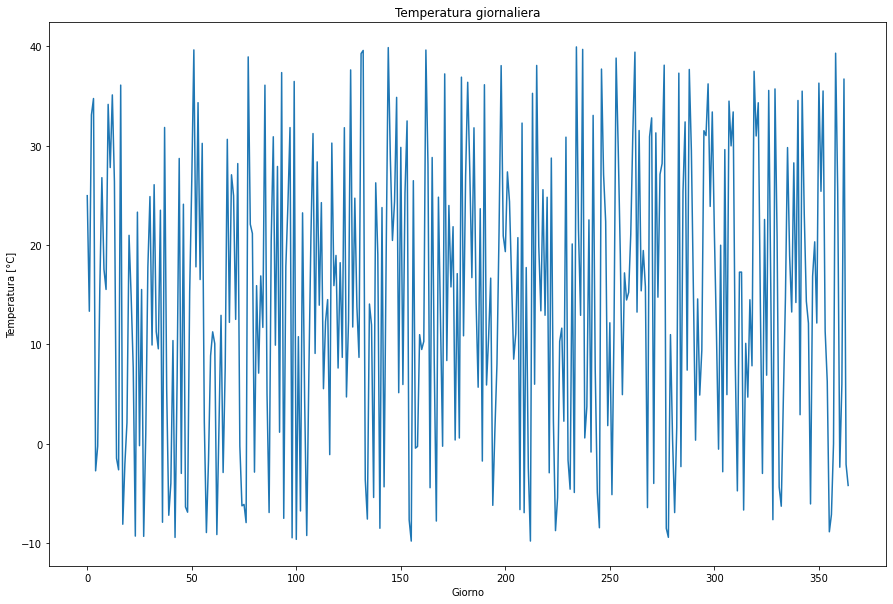

In [5]:
# 1 Uso Numpy per analizzare le temperature di un anno ed estrarre alcune informazioni di base
# 1.1 Genero la distribuzione delle temperature usando il pacchetto random

import numpy as np
import random
import matplotlib.pyplot as plt


n_giorni = 365 # numero di giorni
T_max = 40 # Temperatura minima 
T_min = -10 # Temperatura massima
temperature = np.random.uniform(T_min, T_max, size = n_giorni) # Temperature annue generate con una distribuzione uniforme

# Valutazione delle temperatura media, deviazione standard, temperatura minima e massima
media = np.mean(temperature) # Temperatura media annuale
deviazione_standard = np.std(temperature) # Deviazione standard della media
minima = np.min(temperature) # Temperatura minima
massima = np.max(temperature) # Temperatura massima

# Stampo a schermo le informazioni relative alla media, std, minima e massima
print("La temperatura media annuale è:", media, "°C")
print("La deviazione standard della temperatura media è:", deviazione_standard, "°C")
print("La minima annuale è stata:", minima, "°C")
print("La massima annuale è stata:", massima, "°C")

# Valuto quanti giorni sono stati piu' caldi della media 
giorni_caldi = np.where(temperature >= media, 1 ,0).sum() 
print("La temperatura giornaliera ha superato la media annuale", giorni_caldi, "volte")
# Valuto qual'è stato il primo giorno in cui la temperatura ha superato i 38 gradi
print("La prima volta che la temperatura ha superato i 38 gradi è avvenuto il giorno", (temperature > 38).argmax()+1)


# Conversione da gradi Celsius a Fahrenheit
temperature_F = temperature*1.8 +32



# Grafico delle temperature VS giorno dell'anno
plt.figure(figsize=(15,10))
plt.plot(temperature[:])
plt.xlabel("Giorno")
plt.ylabel("Temperatura [°C]")
plt.title("Temperatura giornaliera")
plt.show()

# Second project with real Data Set for the Temperatures

## Basic operations and checks

Il numero di dati mancanti è: 0


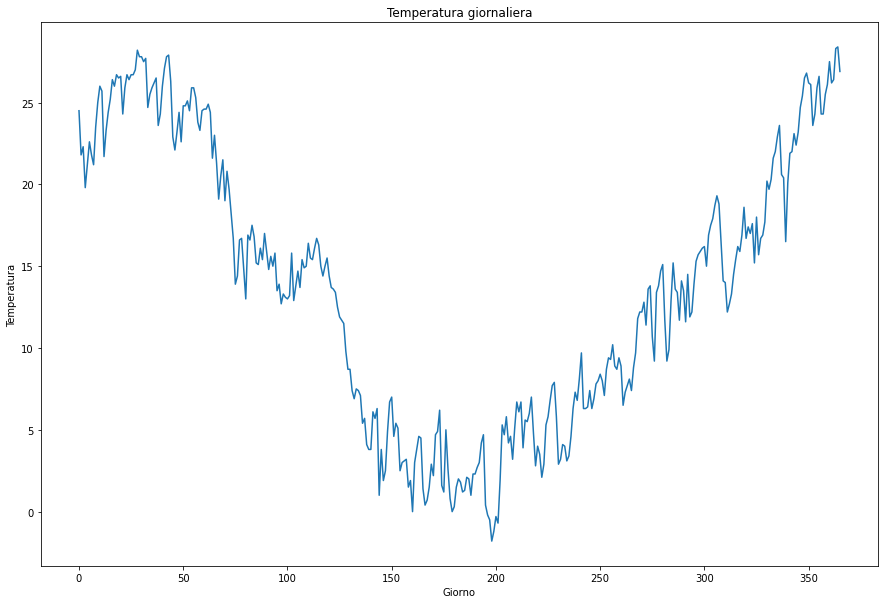

La temperatura media annuale è stati di: 13.72513661202186 gradi Celsius
La temperatura minima è stata di: -1.8 gradi Celsius
La temperatura massima è stata di: 28.4 gradi Celsius
Il numero di giorni con una temperatura superiore alla media è stato di: 187
Il primo giorno in cui la temperatura è scesa sotto lo zero è stato il: 197


In [2]:
# 2 Uso le temperature presente alla pagina web
# https://www.arpa.piemonte.it/rischi_naturali/snippets_arpa_graphs/dati_giornalieri_meteo/?statid=PIE-001292-900-1997-12-23&param=T

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random


df = pd.read_csv("VENARIA CERONDA_t.csv") #Importo il file csv come data frame in Pandas

df_temperature = df.iloc[:,1] # Seleziono la seconda colonna corrispondente alla temperature media giornaliera

# Controllo se ci sono dati mancanti e ne stampo a schermo il numero
print("Il numero di dati mancanti è:", df_temperature.isna().sum())

# Converto la colonna delle temperature in un array di Numpy
temperature = df_temperature.to_numpy()

# Creo il grafico annuale delle temperatura giornaliera
plt.figure(figsize=(15,10))
plt.plot(temperature[:])
plt.xlabel("Giorno")
plt.ylabel("Temperatura")
plt.title("Temperatura giornaliera")
plt.show()

# Operazioni di statistica di base
media = np.mean(temperature) # media
deviazione_media = np.std(temperature) #std
minima = np.min(temperature) # T minima 
massima = np.max(temperature) # T massima

# Stampo a schermo i risultati
print("La temperatura media annuale è stati di:", media, "gradi Celsius")
print("La temperatura minima è stata di:", minima, "gradi Celsius")
print("La temperatura massima è stata di:", massima, "gradi Celsius")

print("Il numero di giorni con una temperatura superiore alla media è stato di:", np.where(temperature > media, 1, 0).sum())
print("Il primo giorno in cui la temperatura è scesa sotto lo zero è stato il:", (temperature <0).argmax() +1)




## More advanced data analysis

In [7]:
df.head() ## Stampo le prime cinque righe del Data Frame

,DATA,Temperatura media (°C),Temperatura massima (°C),Temperatura minima (°C),Temperatura classe,Gradi Giorno riscaldamento base 20 (°C),Gradi Giorno riscaldamento base 18 (°C),Gradi Giorno raffrescamento base 21 (°C)
0,2024-06-30,24.5,30.1,18.8,MZ00,0.0,0.0,3.5
1,2024-07-01,21.8,29.8,16.1,MZ00,0.0,0.0,0.0
2,2024-07-02,22.3,29.8,14.4,MZ00,0.0,0.0,0.0
3,2024-07-03,19.8,24.4,15.5,MZ00,0.1,0.0,0.0
4,2024-07-04,21.2,28.1,13.5,MZ00,0.0,0.0,0.0


In [10]:
# 3 Uso le stesse temperature precedenti. Questa volta mi propongo di individuare
# 3.1 statistiche mensili (media, min, max)
# 3.2 anomalie (giorni molto caldi o freddi)

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

df = pd.read_csv("VENARIA CERONDA_t.csv") # Carico il set di dati

df.set_index(df.columns[0], inplace = True) # Imposto la data come indice 

df = df.iloc[:,[0,1,2]] # Estraggo il data frame con le temperature media giornaliera, temperatura massima e minima

df.columns = ["Temperatura Media", "Temperatura Massima", "Temperatura Minima"] # Per semplicità cambio i nomi delle colonne d'interesse

# Controllo se sono presenti dati mancanti in tutto il DataFrame
if df.isna().any().any() == True:
    print("Attenzione ci sono dei dati mancanti")

df.index = pd.to_datetime(df.index, format="%Y-%m-%d") # converto l'indice a "datetime"
df = df.sort_index() # ordino il DataFrame dal primo giorno presente

df.head()

df = df.drop(index="2024-06-30") # Cancello la prima riga per avere le temperature di un anno dal 01/07/2024 al 30/06/2025

# Statistiche mensili
df_mensile = df.groupby(df.index.to_period("M")).agg({"Temperatura Media": "mean", "Temperatura Massima": "max", "Temperatura Minima": "min"}) # Creo un DataFrame con la media mensile delle temperature
df_mensile.index.name = "Mese" # Cambio il nome della colonna degli indici
df_mensile.columns = ["Temperatura Media Mensile", "Temperatura Massima Mensile", "Temperatura Minima Mensile"]
df_mensile["Std Temperatura Media"] = df.groupby(df.index.to_period("M"))["Temperatura Media"].std()

df_mensile # Stampo il DataFrame con le informazioni relative alla temperatura per ognu mese dell'anno

,Temperatura Media Mensile,Temperatura Massima Mensile,Temperatura Minima Mensile,Std Temperatura Media
Mese,,,,
2024-07,24.925806,35.3,13.5,2.352016
2024-08,25.054839,34.6,16.2,1.494175
2024-09,17.603333,32.2,5.9,2.875639
2024-10,14.551613,22.8,6.2,1.164437
2024-11,6.496667,21.5,-4.0,2.925923
2024-12,2.387097,14.7,-6.0,1.625165
2025-01,2.922581,13.0,-6.5,2.482701
2025-02,5.303571,17.3,-3.2,1.969862
2025-03,9.132258,22.4,-1.0,2.139998


In [11]:
# Estrarre eventuali anomale, i.e. valori che differiscono dalla media mensile per piu' di 2 due deviazioni standard  

df["mese"] = df.index.to_period("M") # Creo una nuova colonna con il mese
df = df.join(df_mensile[["Temperatura Media Mensile","Std Temperatura Media"]], on = "mese") # Unisco tramite il metodo "join" le colonne di interesse
df = df.drop(columns="mese") # elimino la colonna "mese"
df.head()


,Temperatura Media,Temperatura Massima,Temperatura Minima,Temperatura Media Mensile,Std Temperatura Media
DATA,,,,,
2024-07-01,21.8,29.8,16.1,24.925806,2.352016
2024-07-02,22.3,29.8,14.4,24.925806,2.352016
2024-07-03,19.8,24.4,15.5,24.925806,2.352016
2024-07-04,21.2,28.1,13.5,24.925806,2.352016
2024-07-05,22.6,28.4,15.3,24.925806,2.352016


In [12]:
df["Deviazione dalla media"] = (df["Temperatura Media"]-df["Temperatura Media Mensile"]).abs()
df_anomalie  = df[df["Deviazione dalla media"] > 2*df["Std Temperatura Media"]]
df_anomalie # DataFrame delle Anomalie

,Temperatura Media,Temperatura Massima,Temperatura Minima,Temperatura Media Mensile,Std Temperatura Media,Deviazione dalla media
DATA,,,,,,
2024-07-03,19.8,24.4,15.5,24.925806,2.352016,5.125806
2024-09-01,24.4,32.2,17.7,17.603333,2.875639,6.796667
2024-11-01,12.5,21.5,7.0,6.496667,2.925923,6.003333
2024-12-20,6.2,13.8,-1.8,2.387097,1.625165,3.812903
2025-02-26,9.7,17.3,1.9,5.303571,1.969862,4.396429
2025-03-30,13.6,22.4,3.6,9.132258,2.139998,4.467742
2025-03-31,13.8,20.8,5.3,9.132258,2.139998,4.667742
2025-05-31,22.9,29.3,15.1,17.183871,2.664595,5.716129
2025-06-04,16.5,19.1,15.3,24.460000,2.720117,7.960000


# Third project with several real data set for the temperatures

In [255]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -999 significa valore mancante o invalido

df = pd.read_csv("Temperature_Cortenova.csv") # Importo il data det delle temperature del comune di Cortenova (LC) dal 01/01/2004 al 29/01/2026

## Cleaning the data

In [256]:
df.info() # Informazioni sui dati
print("################# Nomi delle colonne ##################")
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8065 entries, 0 to 8064
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Id Sensore                    8065 non-null   int64  
 1   Data-Ora                      8065 non-null   object 
 2   Valore Medio Giornaliero      8065 non-null   float64
 3    Minimo Valore Medio Orario   8065 non-null   float64
 4    Massimo Valore Medio Orario  8065 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 315.2+ KB
################# Nomi delle colonne ##################


Index(['Id Sensore', 'Data-Ora', 'Valore Medio Giornaliero',
       ' Minimo Valore Medio Orario', ' Massimo Valore Medio Orario'],
      dtype='object')

In [257]:
df = df.drop(columns=["Id Sensore"]) # Rimuovo la colonna con il numero del sensore, perché inutile
print("########### le colonne adeso presenti sono: ###############")
print(df.columns)

df.set_index(df.columns[0], inplace=True) # Imposto la prima colonna come indice
df.rename(columns={"Valore Medio Giornaliero":"Temperatura Media °C",
                   " Minimo Valore Medio Orario":"Temperatura Minima °C",
                   " Massimo Valore Medio Orario":"Temperatura Massima °C"
                  }, inplace=True) # Cambio i nomi delle colonne

print("L'indice è del tipo:", type(df.index))

df.index = pd.to_datetime(df.index) # Converto l'indice to "DateTime"
df.index = df.index.date # Rimuovo l'ora della giornata perché inutile ai fini del presente progetto
df.index.name = "Data" # Cambio nome alla colonna dell'indice

#Sostituisco -999.0 con NaN per tutte le colonne
df["Temperatura Media °C"] = df["Temperatura Media °C"].replace(-999.0,np.nan)
df["Temperatura Minima °C"] = df["Temperatura Minima °C"].replace(-999.0,np.nan)
df["Temperatura Massima °C"] = df["Temperatura Massima °C"].replace(-999.0,np.nan)


########### le colonne adeso presenti sono: ###############
Index(['Data-Ora', 'Valore Medio Giornaliero', ' Minimo Valore Medio Orario',
       ' Massimo Valore Medio Orario'],
      dtype='object')
L'indice è del tipo: <class 'pandas.core.indexes.base.Index'>


In [249]:
df.head() # Stampo le prime 5 righe

,Temperatura Media °C,Temperatura Minima °C,Temperatura Massima °C
Data,,,
2004-01-01,NaN,NaN,NaN
2004-01-02,NaN,NaN,NaN
2004-01-03,NaN,NaN,NaN
2004-01-04,NaN,NaN,NaN
2004-01-05,NaN,NaN,NaN


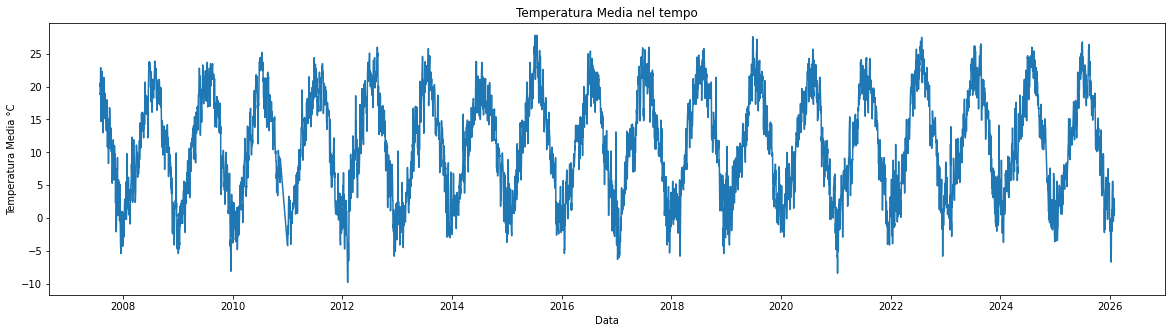

In [258]:
df.dropna(inplace=True) # Elimino le righe contenenti i NaN i dati partobo dal 01/08/2007

plt.figure(figsize=(20,5))
plt.plot(df.index,df["Temperatura Media °C"])
plt.xlabel("Data")
plt.ylabel("Temperatura Media °C")
plt.title("Temperatura Media nel tempo")
plt.show()

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6690 entries, 2007-08-01 to 2026-01-29
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperatura Media °C    6690 non-null   float64
 1   Temperatura Minima °C   6690 non-null   float64
 2   Temperatura Massima °C  6690 non-null   float64
dtypes: float64(3)
memory usage: 209.1+ KB


## Data Analysis

In [135]:
# Ho terminato di pulire i dati e adesso procedo alla loro analisi statistica
df.head()


,Temperatura Media °C,Temperatura Minima °C,Temperatura Massima °C
Data,,,
2007-08-01,18.9,11.6,27.5
2007-08-02,18.8,11.6,28.4
2007-08-03,20.5,13.9,29.7
2007-08-04,20.0,10.3,30.0
2007-08-05,21.2,12.0,29.6


In [259]:
# Faccio statistiche per mese e anno usando "groupby"
df.index = pd.to_datetime(df.index, format="%Y-%m-%d") # converto l'indice a "datetime"

# Creo un Data Frame con i dati ragrupprati per MESE #######################################################################
df_mensile = df.groupby(df.index.to_period("M")).agg({"Temperatura Media °C" : "mean", 
                                                      "Temperatura Minima °C": "min",
                                                      "Temperatura Massima °C": "max"})
df_mensile["Std Temperatura Media Mensile °C"] = df.groupby(df.index.to_period("M"))["Temperatura Media °C"].std()

#Cambio il nome delle colonne e dell'indice
df_mensile.rename(columns={"Temperatura Media °C": "Temperatura Media Mensile °C",
                           "Temperatura Minima °C": "Temperatura Minima Mensile °C",
                          "Temperatura Massima °C": "Temperatura Massima Mensile °C"}, inplace=True)
df_mensile.index.name =  "Mese"
df_mensile.drop("2026-01", inplace=True) # Elimino la riga relativa a Gennaio 2026 perché non completa


#Creo un Data Frame con i dati ragruppati per ANNO #################################################################################
df_anno = df.groupby(df.index.to_period("Y")).agg({"Temperatura Media °C": "mean",
                                                   "Temperatura Minima °C": "min",
                                                  "Temperatura Massima °C": "max"})
df_anno["Std Temperatura Media Annuale °C"] = df.groupby(df.index.to_period("Y"))["Temperatura Media °C"].std()
df_anno.rename(columns={"Temperatura Media °C":"Temperatura Media Annuale °C",
                       "Temperatura Minima °C": "Temperatura Minima Annuale °C",
                       "Temperatura Massima °C": "Temperatura Massima Annuale °C"}, inplace=True)
df_anno.index.name = "Anno"
df_anno.drop("2026", inplace=True) # Elimino l'ultima riga perché non ci sono dati per tutto l'anno



### Data Analysis per Year 

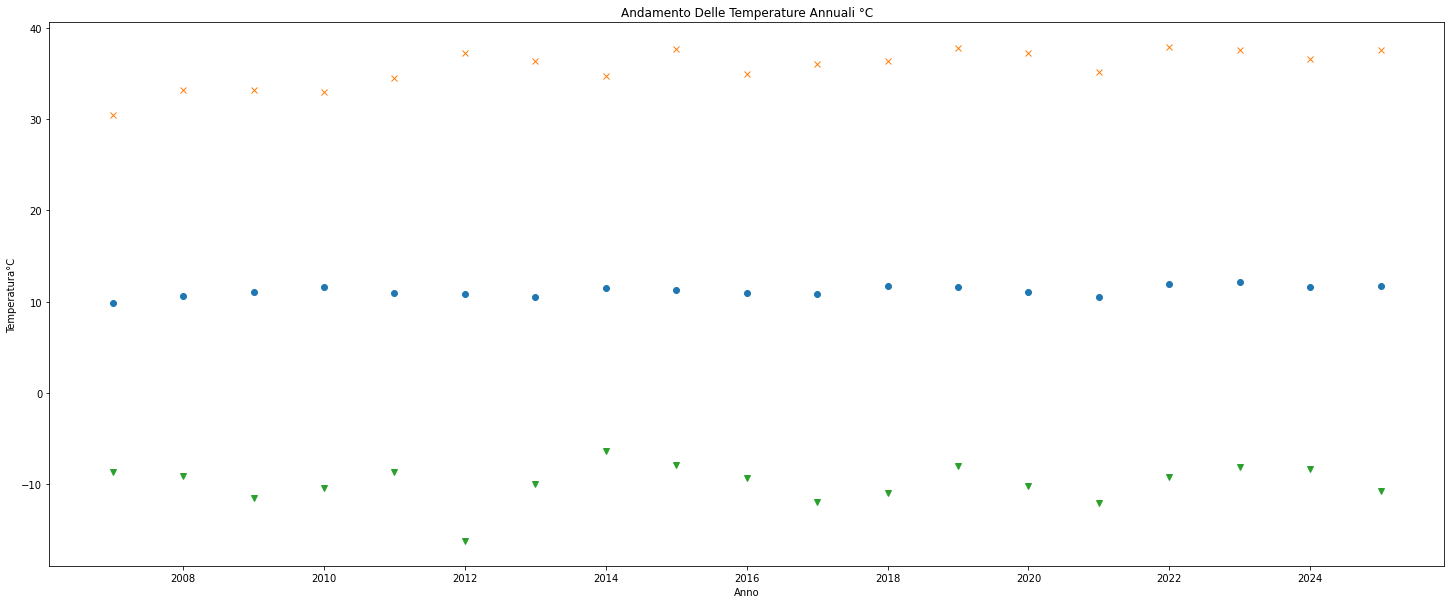

In [241]:
# Andamento delle temperature medie per anno

T_massima = df_anno["Temperatura Massima Annuale °C"].max()
T_minima = df_anno["Temperatura Minima Annuale °C"].min()


plt.figure(figsize=(25,10))
x=df_anno.index.to_timestamp()
plt.plot(x,df_anno["Temperatura Media Annuale °C"], marker="o", linestyle="None")
plt.plot(x,df_anno["Temperatura Massima Annuale °C"], marker="x", linestyle="None")
plt.plot(x,df_anno["Temperatura Minima Annuale °C"], marker="v", linestyle="None")
plt.xlabel("Anno")
plt.ylabel("Temperatura°C")
plt.title("Andamento Delle Temperature Annuali °C")
plt.show()


### Data Analysis per Month

In [260]:
# Estraggo eventuali anomalie dal set di dati iniziali, giorni in cui la temperatura differisce per piu' di due deviazion standard dalla media mensile

df["Mese"] = df.index.to_period("M")
df = df.join(df_mensile[["Temperatura Media Mensile °C","Std Temperatura Media Mensile °C"]], on = "Mese")
df = df.drop(columns="Mese") # Elimino la colonna "Mese"

# Ricavo le anomalie

df["Deviazione dalla media"] = (df["Temperatura Media °C"]-df["Temperatura Media Mensile °C"]).abs()
df_anomalie  = df[df["Deviazione dalla media"] > 2*df["Std Temperatura Media Mensile °C"]]

,Temperatura Media °C,Temperatura Minima °C,Temperatura Massima °C,Temperatura Media Mensile °C,Std Temperatura Media Mensile °C,Deviazione dalla media
Data,,,,,,
2007-08-21,13.0,11.8,14.5,18.812903,2.318583,5.812903
2007-09-27,8.3,8.0,9.3,14.693333,2.814609,6.393333
2008-01-27,9.8,-3.4,20.0,1.558065,2.906977,8.241935
2008-01-28,9.0,1.8,19.3,1.558065,2.906977,7.441935
2008-02-27,8.2,3.7,15.9,2.955172,2.557145,5.244828
...,...,...,...,...,...,...
2025-06-05,16.7,14.9,20.3,22.520000,2.663599,5.820000
2025-09-27,10.4,8.6,11.6,15.933333,2.735253,5.533333
2025-10-24,6.5,1.7,17.2,11.351613,2.384935,4.851613


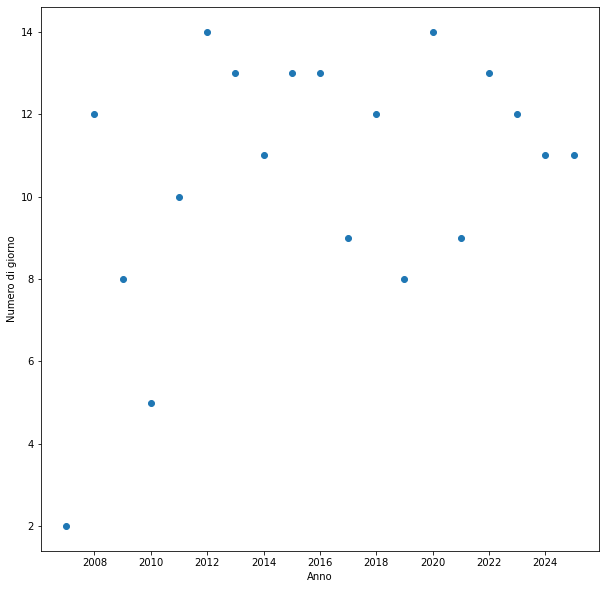

In [284]:
# Numero di anomalie per anno
df_AnomaliePerYear = df_anomalie.groupby(df_anomalie.index.to_period("Y")).agg({"Temperatura Media °C": "count"})

df_AnomaliePerYear.index.name = "Anno" # Cambio il nome dell'indice
df_AnomaliePerYear.rename(columns={"Temperatura Media °C": "Numero di giornate anomale"}, inplace=True) # Cambio il nome della colonna

plt.figure(figsize=(10,10))
plt.scatter(df_AnomaliePerYear.index.to_timestamp(),df_AnomaliePerYear["Numero di giornate anomale"])
plt.xlabel("Anno")
plt.ylabel("Numero di giorno")
plt.show()